Project Objective : Analyze the  AAL’s sales data of the company for the fourth quarter in Australia,
examining it on a state-by-state basis. Provide insights to assist the company in
making data-driven decisions for the upcoming year.
Perform the following steps:
1. Data wrangling
2. Data analysis
3. Data visualization
4. Report generation

#Data wrangling
Ensure that the data is clean and free from any missing or incorrect
entries.


In [190]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [191]:
df_sales= pd.read_csv('AusApparalSales4thQrt2020.csv')
df_sales

,Date,Time,State,Group,Unit,Sales
0,1-Oct-2020,Morning,WA,Kids,8,20000
1,1-Oct-2020,Morning,WA,Men,8,20000
2,1-Oct-2020,Morning,WA,Women,4,10000
3,1-Oct-2020,Morning,WA,Seniors,15,37500
4,1-Oct-2020,Afternoon,WA,Kids,3,7500
...,...,...,...,...,...,...
7555,30-Dec-2020,Afternoon,TAS,Seniors,14,35000
7556,30-Dec-2020,Evening,TAS,Kids,15,37500
7557,30-Dec-2020,Evening,TAS,Men,15,37500
7558,30-Dec-2020,Evening,TAS,Women,11,27500


In [192]:
# all columns related information
df_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7560 entries, 0 to 7559
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Date    7560 non-null   object
 1   Time    7560 non-null   object
 2   State   7560 non-null   object
 3   Group   7560 non-null   object
 4   Unit    7560 non-null   int64 
 5   Sales   7560 non-null   int64 
dtypes: int64(2), object(4)
memory usage: 354.5+ KB


Inspect the data manually to identify missing or incorrect information using the functions isna() and notna(). 

Based on your knowledge of data analytics, include your recommendations for treating missing and incorrect data (dropping the null values or filling them)

In [193]:
# to check for missing values 
df_sales.isna().sum()

Date     0
Time     0
State    0
Group    0
Unit     0
Sales    0
dtype: int64

In [194]:
# tocheck numerical columns statistical analysis
df_sales.describe()

,Unit,Sales
count,7560.000000,7560.000000
mean,18.005423,45013.558201
std,12.901403,32253.506944
min,2.000000,5000.000000
25%,8.000000,20000.000000
50%,14.000000,35000.000000
75%,26.000000,65000.000000
max,65.000000,162500.000000


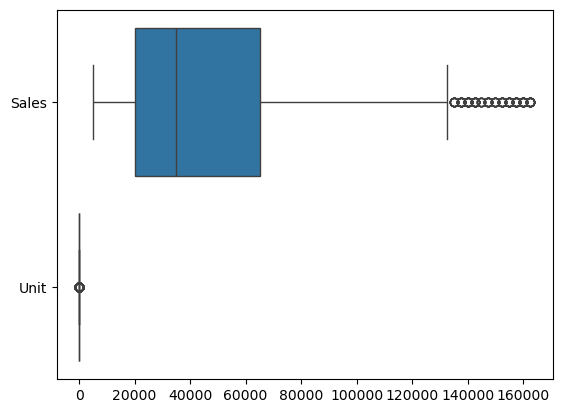

In [195]:
sns.boxplot(data=df_sales[['Sales','Unit']],orient='h' )
plt.show()

Since Outliers found Removing Outliers as 132 rows from 7560 rows so dropping 132 rows.



In [196]:
65000  + (1.5 * 45000 )

132500.0

In [197]:

Q1= df_sales['Sales'].quantile(0.25)
Q3= df_sales['Sales'].quantile(0.75)

IQR = Q3-Q1

Lower_Limit = Q1 - (1.5 * IQR)
Upper_Limit = Q3 + (1.5 * IQR)
print(Q1,Q3,IQR,Lower_Limit,Upper_Limit)



20000.0 65000.0 45000.0 -47500.0 132500.0


In [198]:
df_sales.query('Sales <= -47500 ') 

,Date,Time,State,Group,Unit,Sales


In [199]:
 
 # 123 rows found above upper limit data set can not remove it as it comprises of 
df_sales.query('Sales >= 132500')

,Date,Time,State,Group,Unit,Sales
5082,1-Dec-2020,Afternoon,VIC,Women,63,157500
5083,1-Dec-2020,Afternoon,VIC,Seniors,62,155000
5161,2-Dec-2020,Morning,VIC,Men,56,140000
5162,2-Dec-2020,Morning,VIC,Women,59,147500
5169,2-Dec-2020,Evening,VIC,Men,64,160000
...,...,...,...,...,...,...
7432,29-Dec-2020,Afternoon,VIC,Kids,65,162500
7433,29-Dec-2020,Afternoon,VIC,Men,54,135000
7437,29-Dec-2020,Evening,VIC,Men,54,135000
7515,30-Dec-2020,Morning,VIC,Seniors,65,162500


In [200]:
df_outliers = df_sales.query('Sales >= 132500')
df_sales_copy = df_sales.copy()
df_sales_copy 

,Date,Time,State,Group,Unit,Sales
0,1-Oct-2020,Morning,WA,Kids,8,20000
1,1-Oct-2020,Morning,WA,Men,8,20000
2,1-Oct-2020,Morning,WA,Women,4,10000
3,1-Oct-2020,Morning,WA,Seniors,15,37500
4,1-Oct-2020,Afternoon,WA,Kids,3,7500
...,...,...,...,...,...,...
7555,30-Dec-2020,Afternoon,TAS,Seniors,14,35000
7556,30-Dec-2020,Evening,TAS,Kids,15,37500
7557,30-Dec-2020,Evening,TAS,Men,15,37500
7558,30-Dec-2020,Evening,TAS,Women,11,27500


In [201]:
#df_sales.drop(index = df_outliers.index, axis = 0,inplace = True)
#df_sales 

In [202]:
# to check for any duplicate row entries exists.
print(df_sales.duplicated().sum())

0


In [203]:
# to check categorical columns data
df_sales['Time'].unique(),df_sales['State'].unique(),df_sales['Group'].unique()


(array([' Morning', ' Afternoon', ' Evening'], dtype=object),
 array([' WA', ' NT', ' SA', ' VIC', ' QLD', ' NSW', ' TAS'], dtype=object),
 array([' Kids', ' Men', ' Women', ' Seniors'], dtype=object))

In [204]:
# Removing whitespaces before string in below columns 
df_sales['State'] = df_sales['State'].str.strip()
df_sales['Group'] = df_sales['Group'].str.strip()
df_sales['Time'] = df_sales['Time'].str.strip()

# With Above analysis below observations are found 

1.File contains rows = 7560 and columns = 6 

2.There are no missing values found in any columns.  

3.Sales Values looks disperesed as std(Standard Deviation) value is high

4.There are no duplicates found.

5.Whitespaces observed in Time ,State,Group columns at start of value.

6.Date column datatype is object need to convert to datetime.

7.Sales data is dispersed and in box plot show there are outliers with IQR technique upper limit found as 132500. 
       

Data Wrangling--
Choose a suitable data wrangling technique—either data standardization  or normalization. (Normalization is the preferred approach for this problem.)
Share your insights regarding the application of the GroupBy() function for either data chunking or merging, and offer a recommendation based on your analysis.

# normalising for Sales & Unit Column data

In [205]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

In [206]:
df_sales[['Unit_Norm', 'Sales_Norm']] = scaler.fit_transform(df_sales[['Unit','Sales']])
df_sales

,Date,Time,State,Group,Unit,Sales,Unit_Norm,Sales_Norm
0,1-Oct-2020,Morning,WA,Kids,8,20000,0.095238,0.095238
1,1-Oct-2020,Morning,WA,Men,8,20000,0.095238,0.095238
2,1-Oct-2020,Morning,WA,Women,4,10000,0.031746,0.031746
3,1-Oct-2020,Morning,WA,Seniors,15,37500,0.206349,0.206349
4,1-Oct-2020,Afternoon,WA,Kids,3,7500,0.015873,0.015873
...,...,...,...,...,...,...,...,...
7555,30-Dec-2020,Afternoon,TAS,Seniors,14,35000,0.190476,0.190476
7556,30-Dec-2020,Evening,TAS,Kids,15,37500,0.206349,0.206349
7557,30-Dec-2020,Evening,TAS,Men,15,37500,0.206349,0.206349
7558,30-Dec-2020,Evening,TAS,Women,11,27500,0.142857,0.142857


In [207]:
# addes this another scaling method to observe impact on data distribution after removing outliers and different scaling methods
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
df_sales[['Sales_Robust','Unit_Robust']] = scaler.fit_transform(df_sales[['Sales','Unit']])
df_sales

,Date,Time,State,Group,Unit,Sales,Unit_Norm,Sales_Norm,Sales_Robust,Unit_Robust
0,1-Oct-2020,Morning,WA,Kids,8,20000,0.095238,0.095238,-0.333333,-0.333333
1,1-Oct-2020,Morning,WA,Men,8,20000,0.095238,0.095238,-0.333333,-0.333333
2,1-Oct-2020,Morning,WA,Women,4,10000,0.031746,0.031746,-0.555556,-0.555556
3,1-Oct-2020,Morning,WA,Seniors,15,37500,0.206349,0.206349,0.055556,0.055556
4,1-Oct-2020,Afternoon,WA,Kids,3,7500,0.015873,0.015873,-0.611111,-0.611111
...,...,...,...,...,...,...,...,...,...,...
7555,30-Dec-2020,Afternoon,TAS,Seniors,14,35000,0.190476,0.190476,0.000000,0.000000
7556,30-Dec-2020,Evening,TAS,Kids,15,37500,0.206349,0.206349,0.055556,0.055556
7557,30-Dec-2020,Evening,TAS,Men,15,37500,0.206349,0.206349,0.055556,0.055556
7558,30-Dec-2020,Evening,TAS,Women,11,27500,0.142857,0.142857,-0.166667,-0.166667


Group by function is required to for merging certain sets to find aggregate sales for features like state group and time as well                                                                                 

In [208]:
# different Group by combinations
df_gr_State = pd.DataFrame(df_sales.groupby(['State'])['Sales'].sum().sort_values(ascending = False).round(2))
df_gr_State

,Sales
State,
VIC,105565000
NSW,74970000
SA,58857500
QLD,33417500
TAS,22760000
NT,22580000
WA,22152500


In [209]:
# Identify the group with the highest sales and the group with the lowest sales based on the data provided.
df_gr_Group = pd.DataFrame(df_sales.groupby(['Group'])['Sales'].sum().sort_values(ascending = False).round(2))
df_gr_Group

,Sales
Group,
Men,85750000
Women,85442500
Kids,85072500
Seniors,84037500


In [210]:
df_gr_State_Group = pd.DataFrame(df_sales.groupby(['State','Group'])['Sales'].sum().round(2))
df_gr_State_Group.sort_values(by =['State','Group','Sales'],ascending = False)

Sales
State Group            
WA    Women     5262500
      Seniors   5512500
      Men       5752500
      Kids      5625000
VIC   Women    26482500
      Seniors  26315000
      Men      26407500
      Kids     26360000
TAS   Women     5577500
      Seniors   5650000
      Men       5757500
      Kids      5775000
SA    Women    14970000
      Seniors  14717500
      Men      14655000
      Kids     14515000
QLD   Women     8325000
      Seniors   8190000
      Men       8392500
      Kids      8510000
NT    Women     5652500
      Seniors   5465000
      Men       5762500
      Kids      5700000
NSW   Women    19172500
      Seniors  18187500
      Men      19022500
      Kids     18587500

<function matplotlib.pyplot.show(close=None, block=None)>

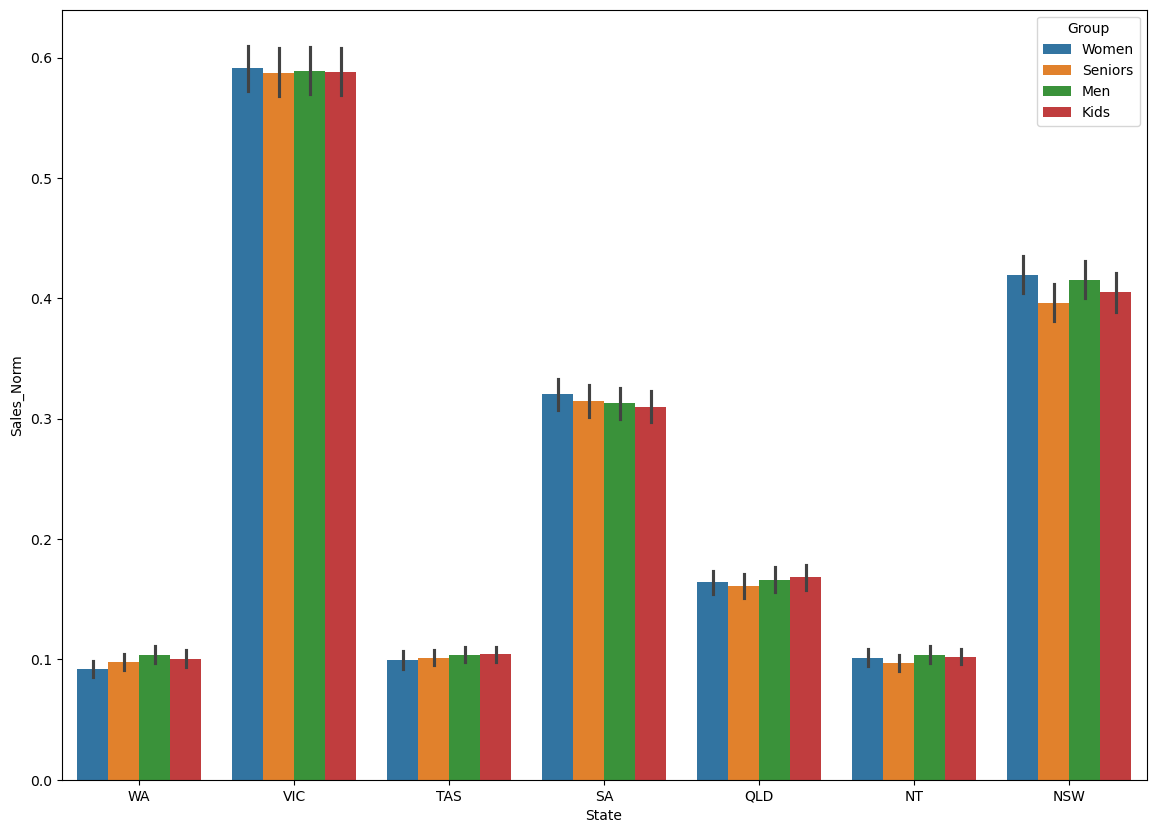

In [211]:
plt.figure(figsize=(14,10))
sns.barplot(data = df_sales.sort_values(by =['State','Group','Sales_Norm'],ascending = False) ,x = 'State', y=  'Sales_Norm' ,hue = 'Group' )
plt.show

# generating weekly monthly and quartelry reports 

In [212]:
# generating weekly monthly and quartelry reports
df_sales['Date'] = pd.to_datetime(df_sales['Date'])
df_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7560 entries, 0 to 7559
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Date          7560 non-null   datetime64[ns]
 1   Time          7560 non-null   object        
 2   State         7560 non-null   object        
 3   Group         7560 non-null   object        
 4   Unit          7560 non-null   int64         
 5   Sales         7560 non-null   int64         
 6   Unit_Norm     7560 non-null   float64       
 7   Sales_Norm    7560 non-null   float64       
 8   Sales_Robust  7560 non-null   float64       
 9   Unit_Robust   7560 non-null   float64       
dtypes: datetime64[ns](1), float64(4), int64(2), object(3)
memory usage: 590.8+ KB


In [213]:
df_sales['Week'] = df_sales['Date'].dt.isocalendar().week
df_sales['Month'] = df_sales['Date'].dt.month
df_sales['Quarter'] = df_sales['Date'].dt.quarter
df_sales

# Generating Timely weekly report
Weekly_Report = df_sales.groupby('Week')[['Sales','Unit']].sum().sort_values(by = ['Sales','Unit'],ascending = False)
Weekly_Report


,Sales,Unit
Week,,
52,31770000,12708
51,31655000,12662
50,31525000,12610
49,29622500,11849
41,27002500,10801
43,26815000,10726
42,26640000,10656
44,21807500,8723
48,21477500,8591


In [214]:
Monthly_Report = df_sales.groupby('Month')[['Sales','Unit']].sum().sort_values(by = ['Sales','Unit'],ascending = False)
Monthly_Report

,Sales,Unit
Month,,
12,135330000,54132
10,114290000,45716
11,90682500,36273


In [215]:
Quartely_Report = df_sales.groupby('Quarter')[['Sales',"Unit"]].sum().sort_values(by = ['Sales','Unit'],ascending = False)
Quartely_Report

,Sales,Unit
Quarter,,
4,340302500,136121


In [216]:
""" Perform descriptive statistical analysis on the data in the Sales and Unit columns. 
Utilize techniques such as mean, median, mode, and standard deviation for this analysis  """

df_sales.describe()

,Date,Unit,Sales,Unit_Norm,Sales_Norm,Sales_Robust,Unit_Robust,Week,Month,Quarter
count,7560,7560.000000,7560.000000,7560.000000,7560.000000,7560.000000,7560.000000,7560.0,7560.000000,7560.0
mean,2020-11-15 04:00:00.000000256,18.005423,45013.558201,0.254054,0.254054,0.222524,0.222524,46.455556,11.000000,4.0
min,2020-10-01 00:00:00,2.000000,5000.000000,0.000000,0.000000,-0.666667,-0.666667,40.0,10.000000,4.0
25%,2020-10-23 00:00:00,8.000000,20000.000000,0.095238,0.095238,-0.333333,-0.333333,43.0,10.000000,4.0
50%,2020-11-15 12:00:00,14.000000,35000.000000,0.190476,0.190476,0.000000,0.000000,46.5,11.000000,4.0
75%,2020-12-08 00:00:00,26.000000,65000.000000,0.380952,0.380952,0.666667,0.666667,50.0,12.000000,4.0
max,2020-12-30 00:00:00,65.000000,162500.000000,1.000000,1.000000,2.833333,2.833333,53.0,12.000000,4.0
std,NaN,12.901403,32253.506944,0.204784,0.204784,0.716745,0.716745,3.786662,0.816551,0.0


<function matplotlib.pyplot.show(close=None, block=None)>

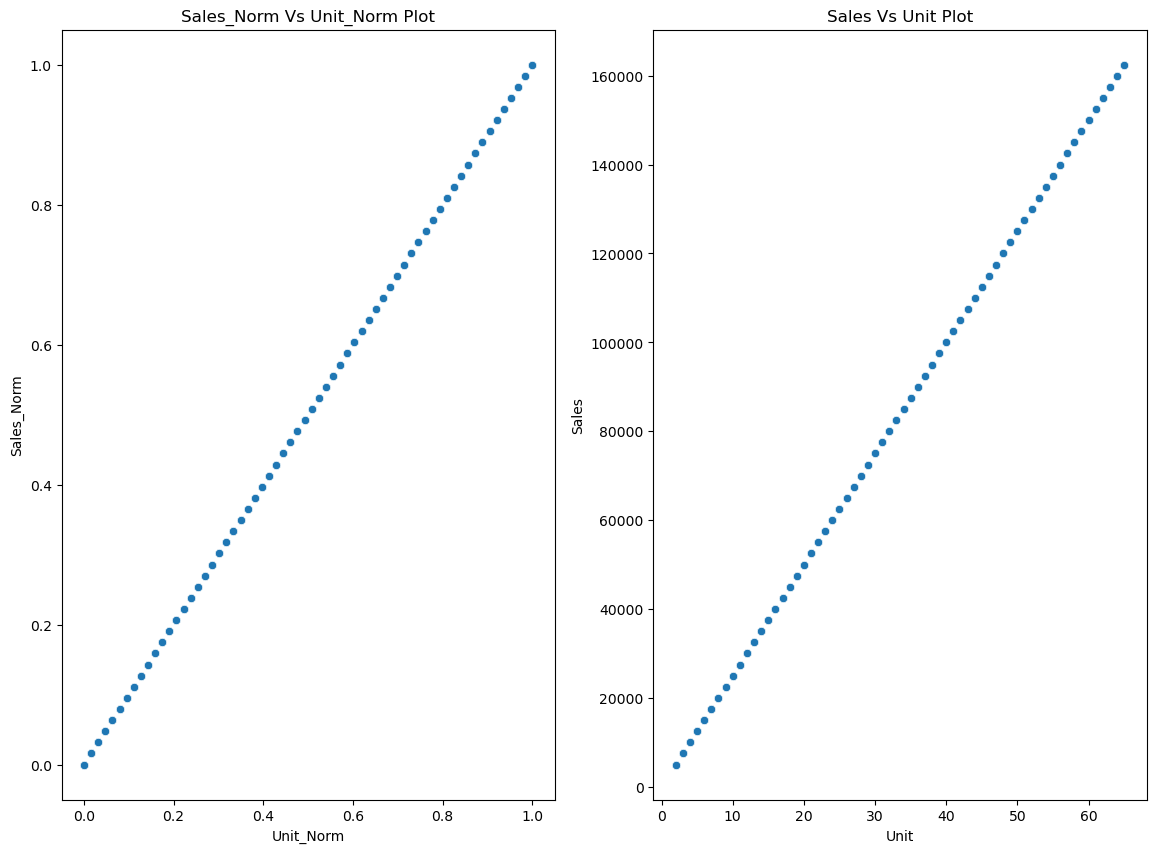

In [217]:
plt.figure(figsize=(14,10))
plt.subplot(1,2,1)
sns.scatterplot(df_sales,x= 'Unit_Norm',y= 'Sales_Norm')
plt.title('Sales_Norm Vs Unit_Norm Plot')

plt.subplot(1,2,2)
sns.scatterplot(df_sales,x= 'Unit',y= 'Sales')
plt.title('Sales Vs Unit Plot')
plt.show

### Report Analysis Findings 
1. 52 Week there is highest Sale and units observed. 
2. In Month of December sale is maximum 
3. Data contains records for quarter four
4. Statistical Analysis indicates that sales data is dispersed with standard deviation of 32253 (If Outliers Dropped std is reduced to @ 29000)
5. There is strong relation between Sales and Unit as Unit increases there is increase in Sales
6. On The basis of data provided Group Mens is with Highest Sale and Group = Seniors having lowest Sale. 
7. State 'VIC' is with Highest Sale and state 'WA' is with lowest Sale


---------------------------------------------------Data Visualisation Section-------------------------------------------------------


State-wise sales analysis for different demographic groups (kids, women, men, and seniors).
### 4.1 – State-wise Sales
This bar chart shows total sales per state for the 4th Quarter 2020.  
VIC leads in sales, while WA is the lowest performer.
### 4.2 – Group-wise Sales
Group-wise sales analysis (Kids, Women, Men, and Seniors) across various states.
Shows Men’s contributes the most to Sale.

Seaborn Visualisation Package is used as it provides option for cleaner view and Works seamlessly with Pandas. Also multiple features can be used to plot the graph

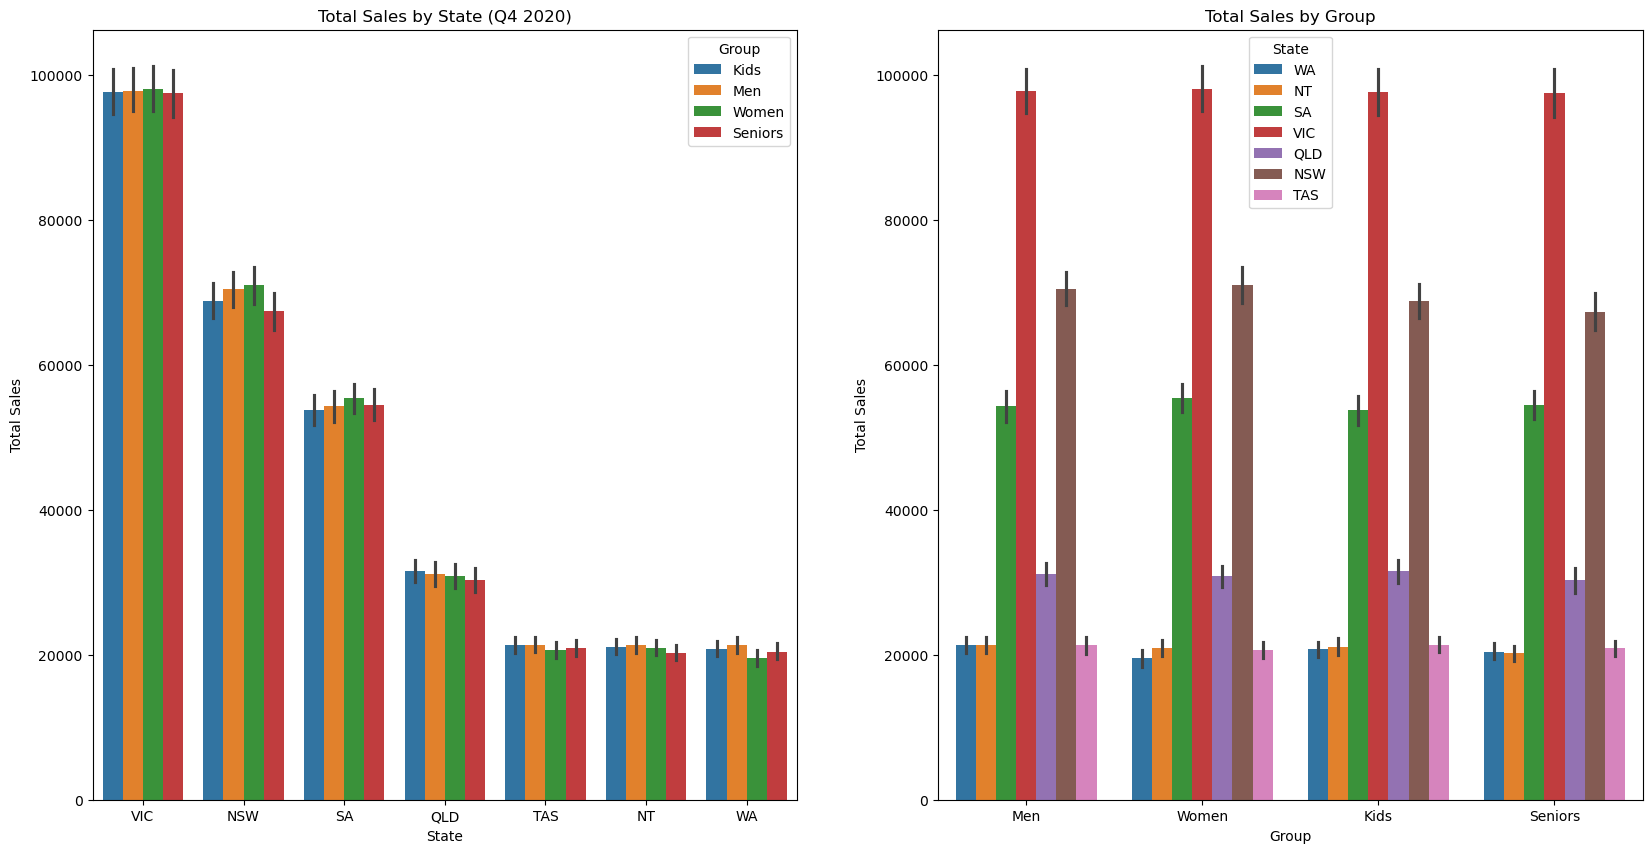

In [218]:
# State-wise Sales
plt.figure(figsize=(20,10))
plt.subplot(1,2,1)
sns.barplot(data=df_sales,x='State', y='Sales',hue = 'Group', order=df_gr_State.index)
plt.title("Total Sales by State (Q4 2020)")
plt.xlabel("State")
plt.ylabel("Total Sales")

# Group-wise Sales
plt.subplot(1,2,2)
sns.barplot(data=df_sales,x='Group', y='Sales',hue = 'State', order=df_gr_Group.index)
plt.title("Total Sales by Group")
plt.xlabel("Group")
plt.ylabel("Total Sales")
plt.show()

In [219]:
df_sales['Day'] = df_sales['Date'].dt.day
df_sales

,Date,Time,State,Group,Unit,Sales,Unit_Norm,Sales_Norm,Sales_Robust,Unit_Robust,Week,Month,Quarter,Day
0,2020-10-01,Morning,WA,Kids,8,20000,0.095238,0.095238,-0.333333,-0.333333,40,10,4,1
1,2020-10-01,Morning,WA,Men,8,20000,0.095238,0.095238,-0.333333,-0.333333,40,10,4,1
2,2020-10-01,Morning,WA,Women,4,10000,0.031746,0.031746,-0.555556,-0.555556,40,10,4,1
3,2020-10-01,Morning,WA,Seniors,15,37500,0.206349,0.206349,0.055556,0.055556,40,10,4,1
4,2020-10-01,Afternoon,WA,Kids,3,7500,0.015873,0.015873,-0.611111,-0.611111,40,10,4,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7555,2020-12-30,Afternoon,TAS,Seniors,14,35000,0.190476,0.190476,0.000000,0.000000,53,12,4,30
7556,2020-12-30,Evening,TAS,Kids,15,37500,0.206349,0.206349,0.055556,0.055556,53,12,4,30
7557,2020-12-30,Evening,TAS,Men,15,37500,0.206349,0.206349,0.055556,0.055556,53,12,4,30
7558,2020-12-30,Evening,TAS,Women,11,27500,0.142857,0.142857,-0.166667,-0.166667,53,12,4,30


In [220]:
#  Daily  to check type command isinstance(Daily,pd.DataFrame) returns true if dataframe else false same way we can check for series by pd.Series

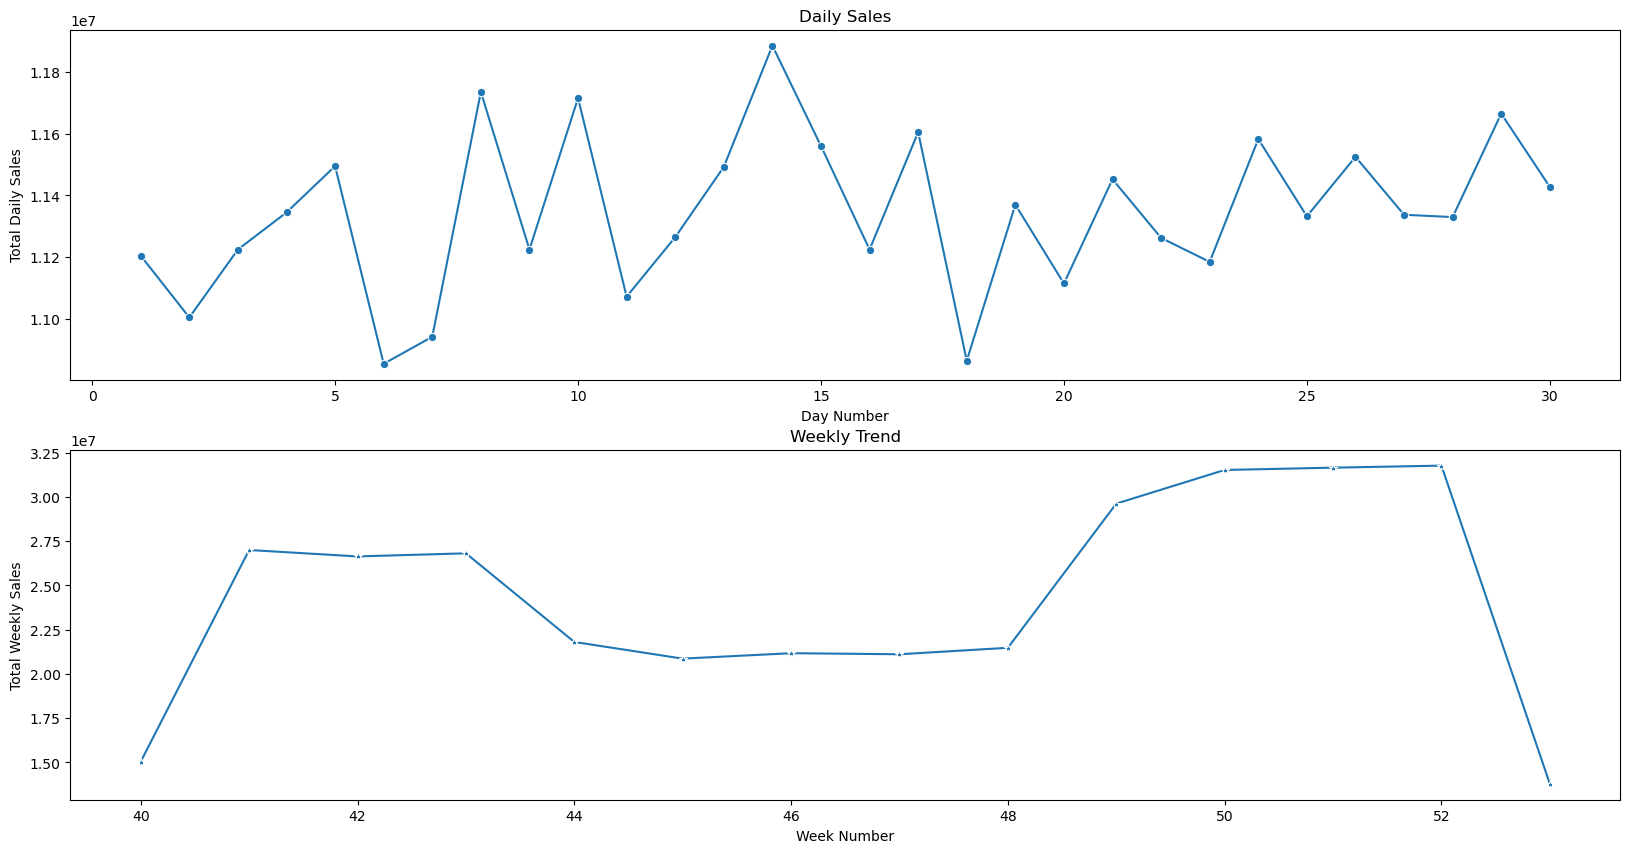

In [221]:
# Daily Trend
Daily = df_sales.groupby("Day")[['Sales','Unit']].sum().reset_index()
plt.figure(figsize = (20,10))
plt.subplot(2,1,1)
sns.lineplot(data=Daily ,x='Day',y='Sales',marker = 'o')
plt.title('Daily Sales')
plt.xlabel("Day Number")
plt.ylabel("Total Daily Sales")

# Weekly 
Weekly = df_sales.groupby("Week")[['Sales',"Unit"]].sum().reset_index()
#plt.figure(figsize = (10,8))
plt.subplot(2,1,2)
sns.lineplot(data=Weekly,x='Week', y='Sales',marker ='*')
plt.title("Weekly Trend")
plt.xlabel("Week Number")
plt.ylabel("Total Weekly Sales")
plt.show()
plt.show()

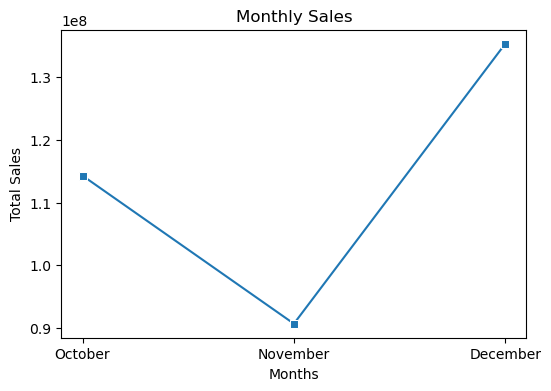

In [222]:
# Monthly & Quarterly Graphs
# Monthly   
import calendar # librabry used for getting month_name 
monthly = df_sales.groupby("Month")[['Sales',"Unit"]].sum().reset_index()
monthly['Month_Name'] = monthly['Month'].apply(lambda x: calendar.month_name[x])

plt.figure(figsize=(6,4))
sns.lineplot(data= monthly,x='Month_Name',y='Sales',marker = 's')
plt.title("Monthly Sales")
plt.xlabel("Months")
plt.ylabel("Total Sales")

"""
# Quarterly Graph -- Since there is only one quarter in data so this graph is not of much use
quarterly = df_sales.groupby("Quarter")[['Sales',"Unit"]].sum().reset_index()
plt.subplot(2,1,2)
sns.lineplot(data=quarterly,x='Quarter',y='Sales',marker = 'p')
plt.title("Quarterly Sales")
plt.xlabel("Quarter")
plt.ylabel("Sales")
"""
plt.show()



Box plot for descriptive statistics.
Distribution plot for any other statistical plotting

- The box plot reveals the range and presence of outliers in both Sales and Units.
- The histogram with KDE shows that sales values are positively skewed, indicating that while most sales are moderate, a few large ones significantly raise the average.


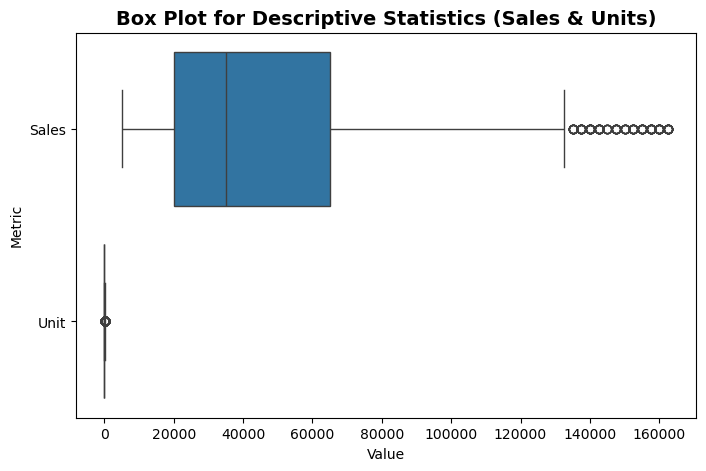

In [223]:
# BOX PLOT for DESCRIPTIVE STATISTICS
plt.figure(figsize=(8,5))
sns.boxplot(data=df_sales[['Sales', 'Unit']], orient='h')
plt.title("Box Plot for Descriptive Statistics (Sales & Units)", fontsize=14, weight='bold')
plt.xlabel("Value")
plt.ylabel("Metric")
plt.show()

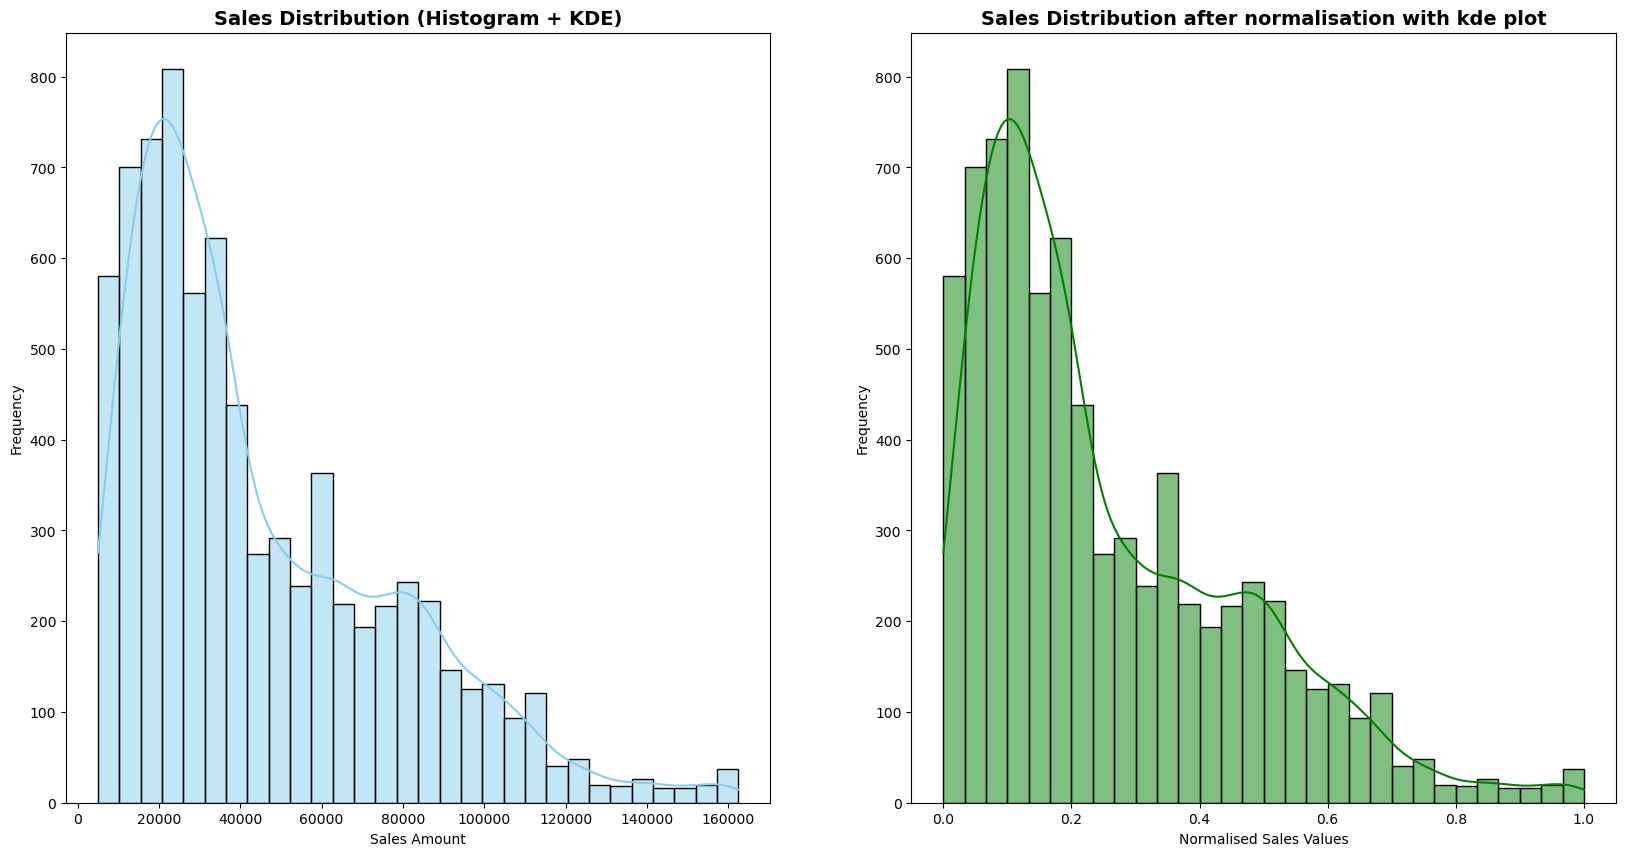

In [224]:
# DISTRIBUTION PLOT for SALES
plt.figure(figsize=(20,10))
plt.subplot(1,2,1)
sns.histplot(df_sales['Sales'], kde=True, color='skyblue', bins=30)
plt.title("Sales Distribution (Histogram + KDE)", fontsize=14, weight='bold')
plt.xlabel("Sales Amount")
plt.ylabel("Frequency")

#after Normalisation histplot 
plt.subplot(1,2,2)
sns.histplot(df_sales['Sales_Norm'], kde= True,color = 'g',bins = 30)
plt.title("Sales Distribution after normalisation with kde plot",fontsize=14, weight='bold')
plt.xlabel("Normalised Sales Values")
plt.ylabel("Frequency")

plt.show()

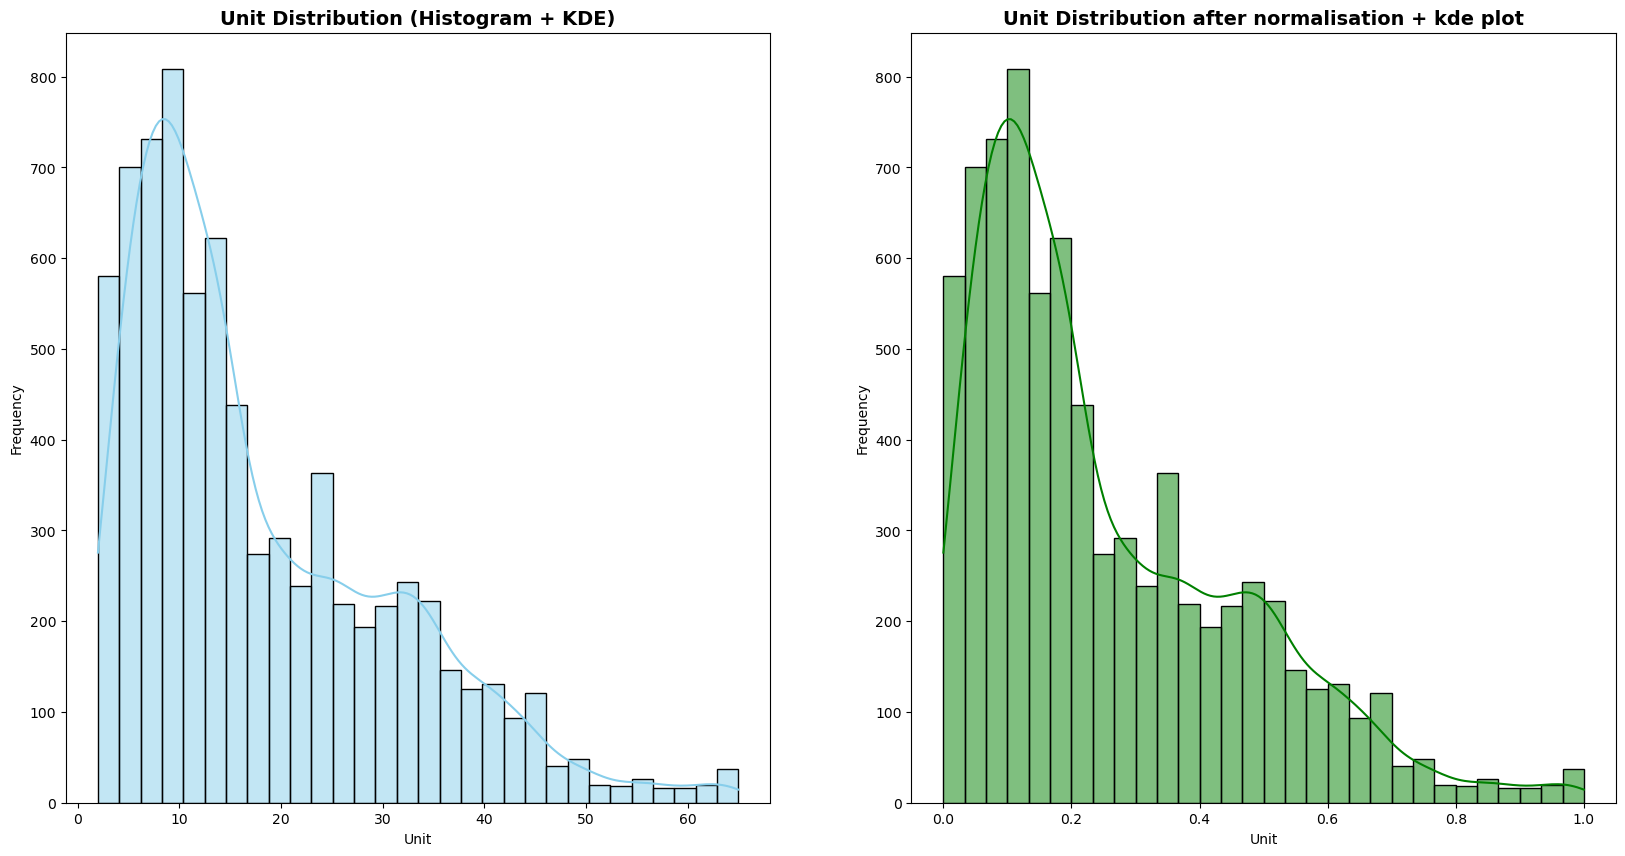

In [225]:
# DISTRIBUTION PLOT for Unit
plt.figure(figsize=(20,10))
plt.subplot(1,2,1)
sns.histplot(df_sales['Unit'], kde=True, color='skyblue', bins=30)
plt.title("Unit Distribution (Histogram + KDE)", fontsize=14, weight='bold')
plt.xlabel("Unit")
plt.ylabel("Frequency")

#after Normalisation histplot 
plt.subplot(1,2,2)
sns.histplot(df_sales['Unit_Norm'], kde= True,color = 'g',bins = 30)
plt.title("Unit Distribution after normalisation + kde plot",fontsize=14, weight='bold')
plt.xlabel("Unit")
plt.ylabel("Frequency")

plt.show()

Final Insight From entire findings:

1. In Month of December sale is maximum and in 52 Week there is highest Sale and units observed  (If Outliers dropped 51 week is highest sale week )
2. Statistical Analysis indicates that sales data is dispersed with standard deviation of 32253 (If Outliers Dropped std is reduced to @29000)
3. There is strong relation between Sales and Unit as Unit increases there is increase in Sales
4. On The basis of data provided Group Mens is with Highest Sale and Group = Seniors having lowest Sale. (If Outliers dropped Kids Group is highest sale group )
5. State 'VIC' is with Highest Sale and state 'WA' is with lowest Sale
6. Importantly Data distribution curve is left skewed even after removing outliers or keeping outliers in dataset indicating data is not showing normal distribution or nearly normal distribution. 
        